In [ ]:
!pip install pandas matplotlib seaborn --quiet

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_train = pd.read_csv("train (1).csv")
df_test = pd.read_csv("test.csv")

In [4]:
df = pd.concat([df_train, df_test], ignore_index=True)

print("Merged dataset shape:", df.shape)
print("\nFirst few rows:\n", df.head())

Merged dataset shape: (7996, 2)

First few rows:
                                                 text label
0  बजार ले जसरी ट्रेन्ड चेन्ज गर्यो यो हेर्दा तत्...     2
1  1000 अंकले घटेको नेप्से 200 अंकले बढ्नु ठूलो क...     1
2  होइन यो सानिमा बैंक ले bonus घोसणा गरेको २ महि...     2
3  खैँ MBJC प्रति कित्तामा रू,10/-ले बढेर आज रू,1...     2
4                                       राम्रो भयो️️     1


In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 text     2
label    0
dtype: int64


In [6]:
df = df.dropna(subset=['text']).reset_index(drop=True)

print("After removing missing text rows:", df.shape)

After removing missing text rows: (7994, 2)


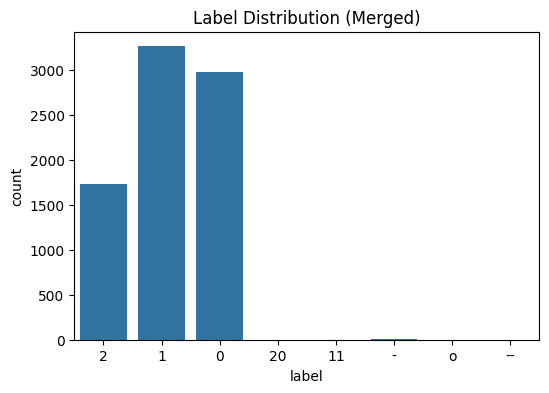


Label counts:
 label
1     3266
0     2985
2     1732
-        6
o        2
20       1
11       1
--       1
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Label Distribution (Merged)")
plt.show()

print("\nLabel counts:\n", df['label'].value_counts())

In [85]:
pip install --upgrade transformers


In [87]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch
import matplotlib.pyplot as plt

# --- 1. Model & Tokenizer ---
MODEL_NAME = "distilbert-base-multilingual-cased"
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# --- 2. Dataset ---
train_texts = ["I love this!", "I hate this!"]
train_labels = [1, 0]
eval_texts = ["This is great!", "This is awful!"]
eval_labels = [1, 0]

def encode_batch(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding="max_length", max_length=128)
    encodings["labels"] = labels
    return encodings

train_dataset = encode_batch(train_texts, train_labels)
eval_dataset = encode_batch(eval_texts, eval_labels)

class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __len__(self):
        return len(self.encodings["labels"])
    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

train_dataset = SimpleDataset(train_dataset)
eval_dataset = SimpleDataset(eval_dataset)

def simple_collate_fn(batch):
    keys = batch[0].keys()
    return {k: torch.stack([d[k] for d in batch]) for k in keys}

# --- 3. TrainingArguments (old style) ---
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,  # We'll control epochs manually
    logging_dir="./logs"
)

# --- 4. Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=simple_collate_fn,
    tokenizer=tokenizer
)

# --- 5. Manual Training Loop for old versions ---
EPOCHS = 3
train_losses = []
eval_losses = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_result = trainer.train()
    train_loss = train_result.training_loss
    train_losses.append(train_loss)

    eval_result = trainer.evaluate()
    eval_loss = eval_result["eval_loss"]
    eval_losses.append(eval_loss)

# --- 6. Plot Loss Curves ---





Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3662631681.py:49: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



Epoch 1/3


Step,Training Loss



Epoch 2/3


Step,Training Loss



Epoch 3/3


Step,Training Loss


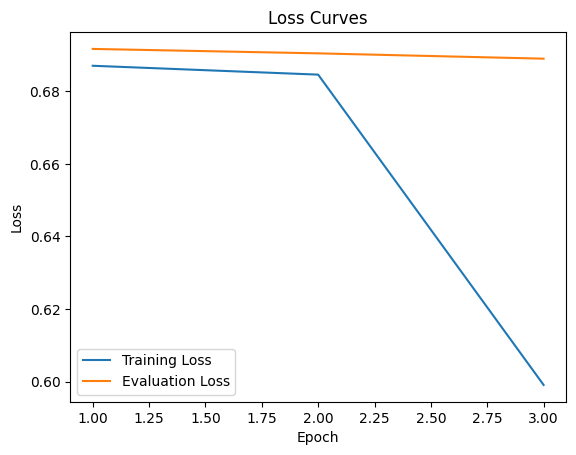

In [88]:
# --- 7. Plot Loss Curves ---
plt.plot(range(1, EPOCHS+1), train_losses, label="Training Loss")
plt.plot(range(1, EPOCHS+1), eval_losses, label="Evaluation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()

